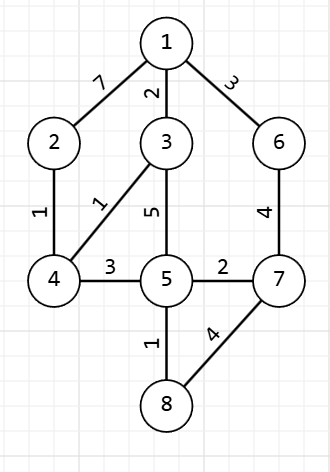

In [1]:
def dfs_shortest_path(matrix, start, end):
    n = len(matrix)
    visited = [False] * n
    min_path = []
    min_cost = float('inf')

    def dfs(current, path, cost):
        nonlocal min_cost, min_path

        # Если дошли до цели
        if current == end:
            if cost < min_cost:
                min_cost = cost
                min_path = path[:]
            return

        visited[current] = True

        for neighbor in range(n):
            weight = matrix[current][neighbor]

            # Если есть ребро и вершина не посещена
            if weight > 0 and not visited[neighbor]:
                dfs(neighbor, path + [neighbor], cost + weight)

        visited[current] = False  # откат

    dfs(start, [start], 0)

    return min_path, min_cost

In [4]:
graph = [
    [0, 7, 2, 0, 0, 3, 0, 0],
    [7, 0, 0, 1, 0, 0, 0, 0],
    [2, 0, 0, 1, 5, 0, 0, 0],
    [0, 1, 1, 0, 3, 0, 0, 0],
    [0, 0, 5, 3, 0, 0, 2, 1],
    [3, 0, 0, 0, 0, 0, 4, 0],
    [0, 0, 0, 0, 2, 4, 0, 4],
    [0, 0, 0, 0, 1, 0, 4, 0]
]

In [7]:
start = 0
end = 7

path, cost = dfs_shortest_path(graph, start, end)

print("Кратчайший путь:", path)
print("Стоимость:", cost)

Кратчайший путь: [0, 2, 3, 4, 7]
Стоимость: 7


In [65]:
import numpy as np

def create_hexagonal_lattice(m):
    # 1) Создаем нулевую матрицу смежности размера M^2 x M^2
    n_nodes = m * m
    matrix = np.zeros((n_nodes, n_nodes), dtype=int)
    
    # 2) Заполнение матрицы по условиям
    for v in range(n_nodes):
        r = v // m  # номер строки
        c = v % m   # номер столбца
        
        # Проверка условий для "узловых" точек решетки
        condition1 = (r % 4 == 0 and c % 2 == 1)
        condition2 = (r % 4 == 2 and c % 2 == 0)
        
        if condition1 or condition2:
            # Связь вверх
            if r > 0:
                matrix[v][v - m] = matrix[v - m][v] = 1
            
            # Связь вниз-вправо
            if r < (m - 1) and c < (m - 1):
                matrix[v][v + m + 1] = matrix[v + m + 1][v] = 1
            
            # Связь вниз-влево
            if r < (m - 1) and c > 0:
                matrix[v][v + m - 1] = matrix[v + m - 1][v] = 1
                
    # 3) Удаление лишних вершин (со степенью < 2)
    new_size = m*m
    for x in range(3):
        for_del = []
        for row_num in range(new_size):
            # if count(set(matrix[row_num])) <= 2:
            if sum(matrix[row_num]) < 2:
                for_del.append(row_num)
    
        # Удаляем строки (axis=0) и столбцы (axis=1) одновременно
        # Сначала удаляем строки
        matrix = np.delete(matrix, for_del, axis=0)
        # Затем из результата удаляем столбцы
        matrix = np.delete(matrix, for_del, axis=1)

        new_size = len(matrix)
                        
    return matrix

In [68]:
# Пример использования
m_size = 7
adj_matrix = create_hexagonal_lattice(m_size)
adj_matrix

array([[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
       [0,

In [74]:
import time
import matplotlib.pyplot as plt

sizes = [4, 5, 6, 7, 8, 9] # Значения M
times = []
live_vertics = []

for M in sizes:
    graph = create_hexagonal_lattice(M)
    live_vertics.append(len(graph))
    nodes = list(range(M))
    if not nodes: continue
    
    start, end = nodes[0], nodes[-1]
    
    start_time = time.time()
    for _ in range(100): # 100 повторов 
        _ = dfs_shortest_path(graph, start, end)
    end_time = time.time()
    # умножить на 100 чтобы размерность вывода соответствовала секундам
    avg_time = (end_time - start_time) / 100 * 100
    times.append(avg_time)
    print(f"Завершено для М: {M}, время: {avg_time}")

Завершено для М: 4, время: 0.0019998550415039062
Завершено для М: 5, время: 0.006002664566040039
Завершено для М: 6, время: 0.02899789810180664
Завершено для М: 7, время: 0.07997369766235352
Завершено для М: 8, время: 1.8363847732543945
Завершено для М: 9, время: 9.37249231338501


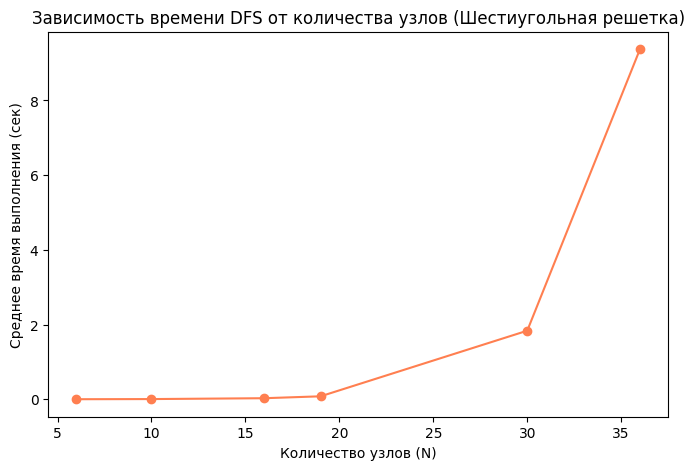

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(live_vertics, times, marker='o', color='coral')
plt.title("Зависимость времени DFS от количества узлов (Шестиугольная решетка)")
plt.xlabel("Количество узлов (N)")
plt.ylabel("Среднее время выполнения (сек)")
# plt.grid(True)
plt.show()